# Φάση Δ: Advanced Technique

Εμείς επιλέξαμε το K-Means


In [22]:
# Φάση Δ: Advanced Technique 
from pyspark.sql import SparkSession
import pyspark.sql.functions as F
from pyspark.ml.fpm import FPGrowth
from pyspark.ml.clustering import KMeans
from pyspark.ml.feature import PCA

spark = SparkSession.builder \
    .appName("Advanced_Techniques") \
    .master("local[*]") \
    .config("spark.driver.memory", "4g") \
    .config("spark.executor.memory", "4g") \
    .getOrCreate()

# --- 1. ASSOCIATION RULES ---
print("Εξαγωγή Κανόνων Συσχέτισης...")
df_silver = spark.read.parquet("../data/train_silver.parquet")

transactions_df = df_silver.withColumn(
    "items",
    F.array_remove(F.array(
        F.when(F.col("stroke") == 1, "Stroke").otherwise(""),
        F.when(F.col("hypertension") == 1, "Hypertension").otherwise(""),
        F.when(F.col("heart_disease") == 1, "Heart_Disease").otherwise(""),
        F.when(F.col("age") > 65, "Age_>_65").otherwise("")
    ), "")
).filter(F.size("items") > 0).select("items")

fpGrowth = FPGrowth(itemsCol="items", minSupport=0.01, minConfidence=0.1) 
rules = fpGrowth.fit(transactions_df).associationRules

print("Κανόνες Κινδύνου για Εγκεφαλικό:")
rules.filter(F.array_contains(F.col("consequent"), "Stroke")).sort(F.col("lift").desc()).show(truncate=False)

# --- 2. CLUSTERING (K-MEANS) ---
print("Εκτέλεση K-Means...")
train_gold = spark.read.parquet("../data/train_gold.parquet")
kmeans = KMeans(featuresCol="features", predictionCol="cluster", k=2, seed=22390225)
#kmeans = KMeans(featuresCol="features", predictionCol="cluster", seed=22390225)

kmeans_preds = kmeans.fit(train_gold).transform(train_gold)

pca = PCA(k=2, inputCol="features", outputCol="pca_features")
kmeans_pca = pca.fit(kmeans_preds).transform(kmeans_preds)

kmeans_pca.select("stroke", "cluster", "pca_features").write.mode("overwrite").parquet("../data/preds_kmeans.parquet")
#spark.stop()

Εξαγωγή Κανόνων Συσχέτισης...
Κανόνες Κινδύνου για Εγκεφαλικό:
+-------------------------+----------+-------------------+------------------+--------------------+
|antecedent               |consequent|confidence         |lift              |support             |
+-------------------------+----------+-------------------+------------------+--------------------+
|[Hypertension, Age_>_65] |[Stroke]  |0.23076923076923078|1.2396878483835005|0.03776978417266187 |
|[Heart_Disease, Age_>_65]|[Stroke]  |0.21014492753623187|1.128894489953091 |0.026079136690647483|
|[Heart_Disease]          |[Stroke]  |0.18018018018018017|0.9679244461853157|0.03597122302158273 |
|[Age_>_65]               |[Stroke]  |0.1671018276762402 |0.8976677892559377|0.11510791366906475 |
|[Hypertension]           |[Stroke]  |0.14039408866995073|0.7541943314057257|0.051258992805755396|
+-------------------------+----------+-------------------+------------------+--------------------+

Εκτέλεση K-Means...


Εύρεση βέλτιστου K με την Elbow Method...
Για K = 2, το Training Cost (WSSSE) είναι: 139595.55
Για K = 3, το Training Cost (WSSSE) είναι: 136323.58
Για K = 4, το Training Cost (WSSSE) είναι: 117132.24
Για K = 5, το Training Cost (WSSSE) είναι: 107692.13
Για K = 6, το Training Cost (WSSSE) είναι: 99573.13
Για K = 7, το Training Cost (WSSSE) είναι: 95087.57
Για K = 8, το Training Cost (WSSSE) είναι: 90680.53


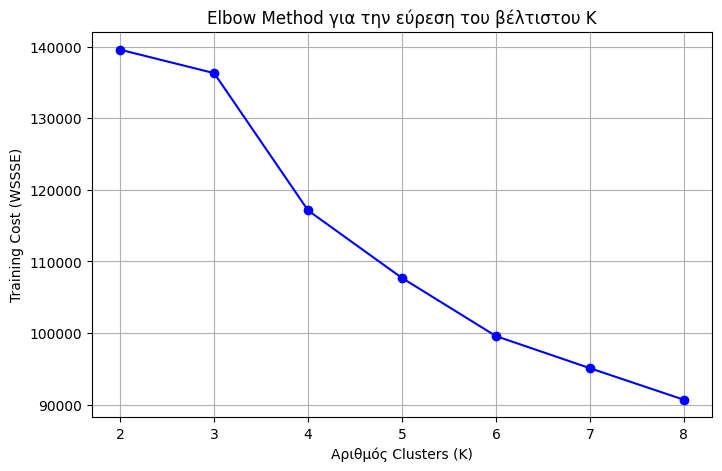

In [23]:
# K Means μέσω Elbow Method
# Kmeans μέσω elbow method
import matplotlib.pyplot as plt
import pandas as pd

print("Εύρεση βέλτιστου K με την Elbow Method...")

# Διαβάζουμε τα χρυσά δεδομένα (αν δεν είναι ήδη φορτωμένα)
train_gold = spark.read.parquet("../data/train_gold.parquet")

# Λίστα για την αποθήκευση του κόστους (Within Set Sum of Squared Errors)
costs = []
k_range = range(2, 9)  # Δοκιμάζουμε k από 2 έως 8

for k_val in k_range:
    # Εκπαίδευση του μοντέλου για το τρέχον k
    km = KMeans(featuresCol="features", k=k_val, seed=42)
    model = km.fit(train_gold)
    
    # Στο PySpark, το trainingCost μας δίνει το WSSSE
    cost = model.summary.trainingCost
    costs.append(cost)
    print(f"Για K = {k_val}, το Training Cost (WSSSE) είναι: {cost:.2f}")

# Δημιουργία γραφήματος για την οπτικοποίηση του "αγκώνα"
plt.figure(figsize=(8, 5))
plt.plot(list(k_range), costs, marker='o', linestyle='-', color='b')
plt.xlabel('Αριθμός Clusters (K)')
plt.ylabel('Training Cost (WSSSE)')
plt.title('Elbow Method για την εύρεση του βέλτιστου K')
plt.grid(True)
plt.show()

# --- Σημείωση: Αφού δεις το γράφημα, επιλέγεις το K εκεί που "σπάει" η καμπύλη ---

Εύρεση βέλτιστου K με το Silhouette Score...
Για K = 2, το Silhouette Score είναι: 0.4433
Για K = 3, το Silhouette Score είναι: 0.1774
Για K = 4, το Silhouette Score είναι: 0.2284
Για K = 5, το Silhouette Score είναι: 0.2606
Για K = 6, το Silhouette Score είναι: 0.2863
Για K = 7, το Silhouette Score είναι: 0.2806
Για K = 8, το Silhouette Score είναι: 0.2813


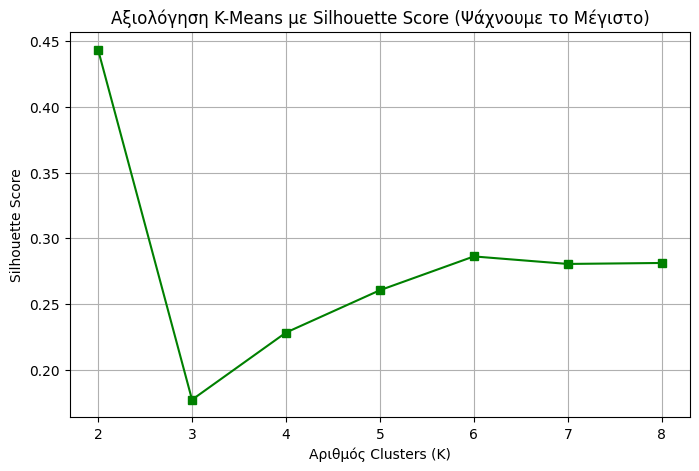

In [24]:
# K Means μέσω Silhouette Score
# K Means μέσω Silhouette Score
import matplotlib.pyplot as plt
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

print("Εύρεση βέλτιστου K με το Silhouette Score...")

# Υποθέτουμε ότι το train_gold υπάρχει ήδη (π.χ. train_gold = spark.read.parquet("../data/train_gold.parquet"))

silhouette_scores = []
k_range = range(2, 9)  # Δοκιμάζουμε K από 2 έως 8

# Ορίζουμε τον Αξιολογητή (Evaluator)
# Σημείωση: Χρησιμοποιούμε predictionCol="cluster" όπως το είχες ορίσει αρχικά
evaluator = ClusteringEvaluator(predictionCol="cluster", featuresCol="features", metricName="silhouette")

for k_val in k_range:
    # 1. Ορισμός και εκπαίδευση του μοντέλου
    km = KMeans(featuresCol="features", predictionCol="cluster", k=k_val, seed=42)
    model = km.fit(train_gold)
    
    # 2. Παραγωγή προβλέψεων (τα assignments στα clusters)
    predictions = model.transform(train_gold)
    
    # 3. Υπολογισμός του Silhouette Score
    score = evaluator.evaluate(predictions)
    silhouette_scores.append(score)
    print(f"Για K = {k_val}, το Silhouette Score είναι: {score:.4f}")

# Δημιουργία γραφήματος για την οπτικοποίηση των σκορ
plt.figure(figsize=(8, 5))
plt.plot(list(k_range), silhouette_scores, marker='s', linestyle='-', color='g')
plt.xlabel('Αριθμός Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Αξιολόγηση K-Means με Silhouette Score (Ψάχνουμε το Μέγιστο)')
plt.grid(True)
plt.show()

# --- Σημείωση: Επίλεξε το K που αντιστοιχεί στο υψηλότερο σημείο του γραφήματος ---

Προετοιμασία δεδομένων για το Plot των K-Means Clusters...


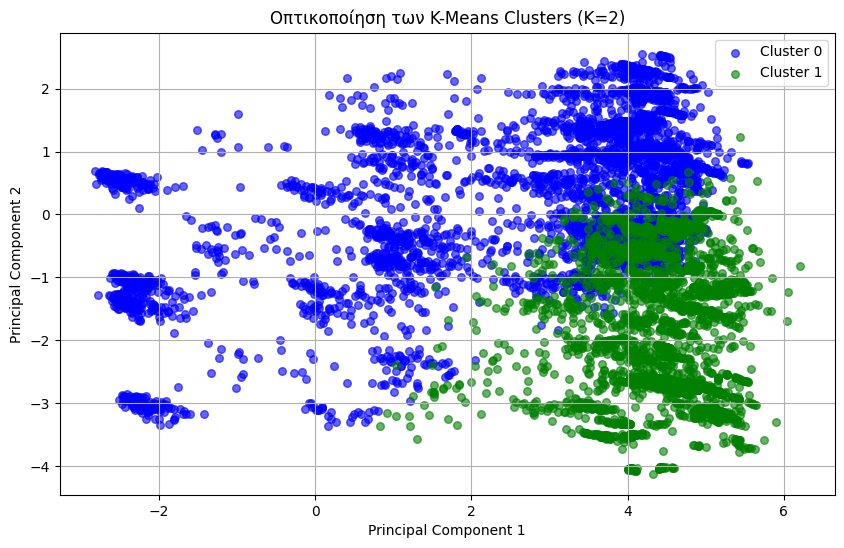

In [25]:
import matplotlib.pyplot as plt
import pandas as pd

print("Προετοιμασία δεδομένων για το Plot των K-Means Clusters...")
# Προσοχή: Εδώ επιλέγουμε τη στήλη 'cluster', ΟΧΙ το 'stroke'
plot_df = kmeans_pca.select("pca_features", "cluster").toPandas()

# Εξαγωγή των PC1 και PC2
plot_df['PC1'] = plot_df['pca_features'].apply(lambda vec: float(vec[0]))
plot_df['PC2'] = plot_df['pca_features'].apply(lambda vec: float(vec[1]))

plt.figure(figsize=(10, 6))

# Ορίζουμε 3 χρώματα για τα 3 clusters (0, 1, 2)
colors = {0: 'blue', 1: 'green', 2: 'red'}

# Φτιάχνουμε τα σημεία για κάθε cluster
for cluster_id in sorted(plot_df['cluster'].unique()):
    cluster_data = plot_df[plot_df['cluster'] == cluster_id]
    plt.scatter(cluster_data['PC1'], cluster_data['PC2'], 
                alpha=0.6, label=f'Cluster {cluster_id}', 
                color=colors.get(cluster_id, 'black'), s=30)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title(f'Οπτικοποίηση των K-Means Clusters (K={kmeans.getK()})')
plt.legend()
plt.grid(True)
plt.show()

In [26]:
import pandas as pd

# 1. Επιλέγουμε μόνο το cluster και το stroke από τις προβλέψεις
pdf_stroke_test = kmeans_preds.select("cluster", "stroke").toPandas()

# 2. Υπολογίζουμε το ποσοστό (%) εμφάνισης stroke ανά cluster
print("=" * 50)
print("TEST: ΠΟΣΟΣΤΟ (%) STROKE ANA CLUSTER")
print("=" * 50)

# Το mean() σε binary στήλη (0/1) πολλαπλασιαζόμενο επί 100 μας δίνει το ποσοστό %
stroke_profile = pdf_stroke_test.groupby("cluster").mean() * 100
print(stroke_profile.round(1).to_string())

TEST: ΠΟΣΟΣΤΟ (%) STROKE ANA CLUSTER
         stroke
cluster        
0          39.1
1          65.3


In [27]:
import pandas as pd
import numpy as np
import pyspark.sql.functions as F

# 1. Φόρτωση των DataFrames
df_silver = spark.read.parquet("../data/train_silver.parquet")
train_gold = spark.read.parquet("../data/train_gold.parquet")

# 2. Native PySpark Extraction των Categorical Labels από τα Metadata
human_categorical_names = []
cat_cols = [field.name for field in df_silver.schema.fields if field.name.endswith("_index")]

for col in cat_cols:
    # Παίρνουμε τα metadata της στήλης
    metadata = df_silver.schema[col].metadata
    
    # Αν η στήλη έχει περάσει από StringIndexer, τα labels υπάρχουν έτοιμα εδώ:
    if "ml_attr" in metadata and "vals" in metadata["ml_attr"]:
        distinct_vals = metadata["ml_attr"]["vals"]
    else:
        # Fallback αν δεν υπάρχουν metadata (διαβάζουμε τις τιμές native)
        original_col_name = col.replace("_index", "")
        distinct_vals = [str(row[0]) for row in df_silver.select(original_col_name).distinct().sort(col).collect()]
    
    # Το OneHotEncoder (dropLast=True) πετάει πάντα την τελευταία τιμή
    kept_vals = distinct_vals[:-1]
    
    # Φτιάχνουμε τα τελικά ονόματα
    original_col_name = col.replace("_index", "")
    for val in kept_vals:
        human_categorical_names.append(f"{original_col_name}_{val}")

num_cat_features = len(human_categorical_names)

# 3. Μετατροπή των predictions σε Pandas (Μόνο για το τελικό group/report)
pdf_gold = kmeans_preds.select("features", "cluster").toPandas()
features_matrix = np.vstack(pdf_gold['features'].apply(lambda x: x.toArray()))

# 4. Απομόνωση του categorical κομματιού και δημιουργία του DataFrame
cat_features_matrix = features_matrix[:, 0:num_cat_features]
cat_features_binary = (cat_features_matrix > 0.001).astype(int)

pdf_cat_human = pd.DataFrame(cat_features_binary, columns=human_categorical_names)
pdf_cat_human['cluster'] = pdf_gold['cluster']

# 5. Τελικό Report Ποσοστών
print("\n" + "="*80)
print("=== ΑΝΘΡΩΠΙΝΑ ΠΟΣΟΣΤΑ (%) ΚΑΤΗΓΟΡΙΚΩΝ ΧΑΡΑΚΤΗΡΙΣΤΙΚΩΝ ΑΝΑ CLUSTER ===")
print("="*80)
cat_profile_human = pdf_cat_human.groupby('cluster').mean() * 100
print(cat_profile_human.round(1).T.to_string())


=== ΑΝΘΡΩΠΙΝΑ ΠΟΣΟΣΤΑ (%) ΚΑΤΗΓΟΡΙΚΩΝ ΧΑΡΑΚΤΗΡΙΣΤΙΚΩΝ ΑΝΑ CLUSTER ===
cluster                            0     1
gender_Female                   87.8  11.7
gender_Male                     12.2  88.3
gender_Other                     0.0   0.0
ever_married_Yes                69.1  98.1
ever_married_No                 30.9   1.9
work_type_Private               62.1  73.4
work_type_Self-employed         16.9  20.2
work_type_children              12.4   0.0
work_type_Govt_job               8.2   6.4
work_type_Never_worked           0.4   0.0
Residence_type_Urban            45.1  67.5
Residence_type_Rural            54.9  32.5
smoking_status_never smoked     45.9  29.8
smoking_status_Unknown          23.9  17.5
smoking_status_formerly smoked  17.5  32.5
smoking_status_smokes           12.7  20.1


In [28]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
import pyspark.sql.functions as F
from pyspark.sql.types import IntegerType, DoubleType, FloatType, LongType # <-- Προσθήκη των types

# 1. Φόρτωση του Silver DataFrame
df_silver = spark.read.parquet("../data/train_silver.parquet")

# ==========================================
# ΑΥΤΟΜΑΤΟΣ ΔΙΑΧΩΡΙΣΜΟΣ ΜΕ NATIVE PYSPARK (FIXED)
# ==========================================
# Ελέγχουμε αν το dataType είναι instance των αριθμητικών κλάσεων του Spark
spark_numeric_types = (IntegerType, DoubleType, FloatType, LongType)
all_numeric_cols = [field.name for field in df_silver.schema.fields if isinstance(field.dataType, spark_numeric_types)]

numeric_cols = [c for c in all_numeric_cols if c != "stroke" and not c.endswith("_index")]
cat_cols = [c for c in all_numeric_cols if c.endswith("_index")]

# Quick check για σιγουριά πριν το SMOTE
print(f"Dynamic continuous αριθμητικές στήλες: {numeric_cols}")
print(f"Dynamic κατηγορικοί indexes για το SMOTE: {cat_cols}")

if not numeric_cols and not cat_cols:
    raise ValueError("⚠️ Όπα! Δεν βρέθηκαν αριθμητικές στήλες. Τσέκαρε το schema του df_silver με df_silver.printSchema()")

# 2. Native PySpark Υπολογισμός των STDs
std_exprs = [F.stddev_samp(F.col(c)).alias(c) for c in numeric_cols]
stds_dict = df_silver.select(*std_exprs).first().asDict()

# 3. Ασφαλές SMOTE
pdf_for_smote = df_silver.select(numeric_cols + cat_cols + ["stroke"]).toPandas()
X_res, y_res = SMOTE(random_state=42).fit_resample(pdf_for_smote[numeric_cols + cat_cols], pdf_for_smote["stroke"])

# 4. Εξαγωγή των scaled αριθμητικών χαρακτηριστικών από το Gold Vector
pdf_gold = kmeans_preds.select("features", "cluster").toPandas()
features_matrix = np.vstack(pdf_gold['features'].apply(lambda x: x.toArray()))

# Βρίσκουμε δυναμικά πού ξεκινούν οι αριθμητικές στήλες στο vector
num_cat_features = features_matrix.shape[1] - len(numeric_cols)
numeric_features_scaled = features_matrix[:, num_cat_features:]

# 5. Δημιουργία DataFrame με τις ΠΡΑΓΜΑΤΙΚΕΣ (Unscaled) τιμές
pdf_numeric_unscaled = pd.DataFrame(columns=numeric_cols)
for i, col in enumerate(numeric_cols):
    pdf_numeric_unscaled[col] = numeric_features_scaled[:, i] * stds_dict[col]

# Προσθήκη της στήλης του cluster
pdf_numeric_unscaled['cluster'] = pdf_gold['cluster']

# 6. Τελικό Report ανά Cluster
print("\n" + "="*90)
print("=== ΣΤΑΤΙΣΤΙΚΟ ΠΡΟΦΙΛ ΠΡΑΓΜΑΤΙΚΩΝ ΑΡΙΘΜΗΤΙΚΩΝ ΧΑΡΑΚΤΗΡΙΣΤΙΚΩΝ ΑΝΑ CLUSTER ===")
print("="*90)

cluster_profiles = pdf_numeric_unscaled.groupby('cluster')[numeric_cols].agg(['mean', 'min', 'max', 'std'])

for cluster_id in sorted(pdf_numeric_unscaled['cluster'].unique()):
    print(f"\n--- CLUSTER {cluster_id} ---")
    print(cluster_profiles.loc[cluster_id].unstack(level=1).round(2).to_string())

Dynamic continuous αριθμητικές στήλες: ['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi']
Dynamic κατηγορικοί indexes για το SMOTE: ['gender_index', 'ever_married_index', 'work_type_index', 'Residence_type_index', 'smoking_status_index']

=== ΣΤΑΤΙΣΤΙΚΟ ΠΡΟΦΙΛ ΠΡΑΓΜΑΤΙΚΩΝ ΑΡΙΘΜΗΤΙΚΩΝ ΧΑΡΑΚΤΗΡΙΣΤΙΚΩΝ ΑΝΑ CLUSTER ===

--- CLUSTER 0 ---
                    mean    min     max    std
age                48.95   0.08   83.12  25.23
hypertension        0.08   0.00    1.01   0.27
heart_disease       0.01   0.00    1.05   0.11
avg_glucose_level  80.38  44.84  214.41  31.71
bmi                32.75  12.13   91.85   7.93

--- CLUSTER 1 ---
                     mean    min     max    std
age                 65.10  14.19   83.12  13.61
hypertension         0.13   0.00    1.01   0.33
heart_disease        0.11   0.00    1.05   0.32
avg_glucose_level  116.43  44.92  217.82  50.74
bmi                 36.52  16.72  114.93   6.80
